<a href="https://colab.research.google.com/github/aqihsna/hygd-glaucoma-detection/blob/main/HYGD_Glaucoma_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Setup

In [ ]:
import torch
import numpy as np
import random

seed = 42

torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

np.random.seed(seed)
random.seed(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [ ]:
import torch
print(torch.cuda.is_available())

True


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
dataset_path = "/content/drive/MyDrive/Colab Notebooks/HYGD"
image_dir = dataset_path + "/Images"
label_file = dataset_path + "/Labels.csv"

## Dataset

In [ ]:
import os

print("HYGD contents:", os.listdir(dataset_path))
print("Images folder sample:", os.listdir(image_dir)[:10])
print("Total images:", len(os.listdir(image_dir)))

HYGD contents: ['Labels.csv', 'Images', 'glaucoma_resnet18.pth']
Images folder sample: ['100_7.jpg', '107_1.jpg', '104_3.jpg', '108_0.jpg', '107_2.jpg', '10_1.jpg', '100_2.jpg', '102_0.jpg', '104_5.jpg', '104_2.jpg']
Total images: 747


In [ ]:
import pandas as pd

labels_df = pd.read_csv(label_file)
print(labels_df.head())
print(labels_df.columns)
print(labels_df.shape)

  Image Name  Patient Label  Quality Score  Unnamed: 4
0    0_0.jpg        0  GON+           6.18         NaN
1    1_0.jpg        1  GON+           5.31         NaN
2    1_1.jpg        1  GON+           4.37         NaN
3    2_0.jpg        2  GON+           3.51         NaN
4    2_1.jpg        2  GON+           4.24         NaN
Index(['Image Name', 'Patient', 'Label', 'Quality Score', 'Unnamed: 4'], dtype='object')
(747, 5)


In [ ]:
labels_df = labels_df.drop(columns=["Unnamed: 4"])
print(labels_df.columns)

Index(['Image Name', 'Patient', 'Label', 'Quality Score'], dtype='object')


In [ ]:
labels_df["label"] = labels_df["Label"].map({
    "GON-": 0,
    "GON+": 1
})

print(labels_df[["Label", "label"]].head())
print(labels_df["label"].value_counts())

  Label  label
0  GON+      1
1  GON+      1
2  GON+      1
3  GON+      1
4  GON+      1
label
1    548
0    199
Name: count, dtype: int64


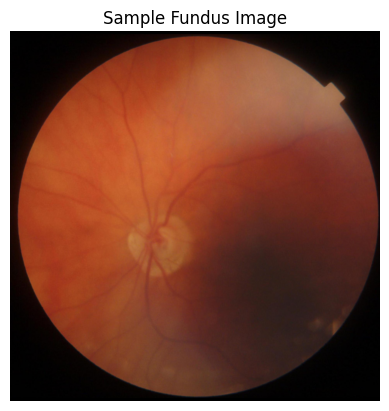

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import os

img_name = labels_df.iloc[0]["Image Name"]
img_path = os.path.join(image_dir, img_name)

img = Image.open(img_path)
plt.imshow(img)
plt.title("Sample Fundus Image")
plt.axis("off")
plt.show()

## Model

In [ ]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    labels_df,
    test_size=0.3,
    stratify=labels_df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label"],
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 522
Validation: 112
Test: 113


In [ ]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

class FundusDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_name = self.dataframe.loc[idx, "Image Name"]
        label = self.dataframe.loc[idx, "label"]

        img_path = os.path.join(self.image_dir, img_name)
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)

In [ ]:
train_dataset = FundusDataset(train_df, image_dir, transform=train_transform)
val_dataset = FundusDataset(val_df, image_dir, transform=val_transform)
test_dataset = FundusDataset(test_df, image_dir, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print("DataLoaders ready")

DataLoaders ready


In [ ]:
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to(device)

print("Using device:", device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 111MB/s]


Using device: cuda


In [ ]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / len(loader), correct / total

In [ ]:
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0
    correct = 0
    total = 0

    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            probs = torch.softmax(outputs, dim=1)[:, 1]
            preds = outputs.argmax(dim=1)

            running_loss += loss.item()
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    return running_loss / len(loader), correct / total, all_labels, all_preds, all_probs

In [ ]:
num_epochs = 5

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, _, _, _ = evaluate(model, val_loader, criterion, device)

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f}, Val Acc:   {val_acc:.4f}")
    print("-" * 30)

Epoch 1/5
Train Loss: 0.0903, Train Acc: 0.9751
Val Loss:   0.0495, Val Acc:   0.9821
------------------------------
Epoch 2/5
Train Loss: 0.0234, Train Acc: 0.9923
Val Loss:   0.0823, Val Acc:   0.9821
------------------------------
Epoch 3/5
Train Loss: 0.0461, Train Acc: 0.9828
Val Loss:   0.0416, Val Acc:   0.9821
------------------------------
Epoch 4/5
Train Loss: 0.0288, Train Acc: 0.9923
Val Loss:   0.0126, Val Acc:   1.0000
------------------------------
Epoch 5/5
Train Loss: 0.0149, Train Acc: 0.9962
Val Loss:   0.0091, Val Acc:   1.0000
------------------------------


## Results

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

test_loss, test_acc, y_true, y_pred, y_prob = evaluate(model, test_loader, criterion, device)

print("Test Accuracy:", test_acc)
print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["Normal", "Glaucoma"]))

print("ROC-AUC:", roc_auc_score(y_true, y_prob))

Test Accuracy: 0.9557522123893806
Confusion Matrix:
[[26  4]
 [ 1 82]]

Classification Report:
              precision    recall  f1-score   support

      Normal       0.96      0.87      0.91        30
    Glaucoma       0.95      0.99      0.97        83

    accuracy                           0.96       113
   macro avg       0.96      0.93      0.94       113
weighted avg       0.96      0.96      0.95       113

ROC-AUC: 0.989156626506024


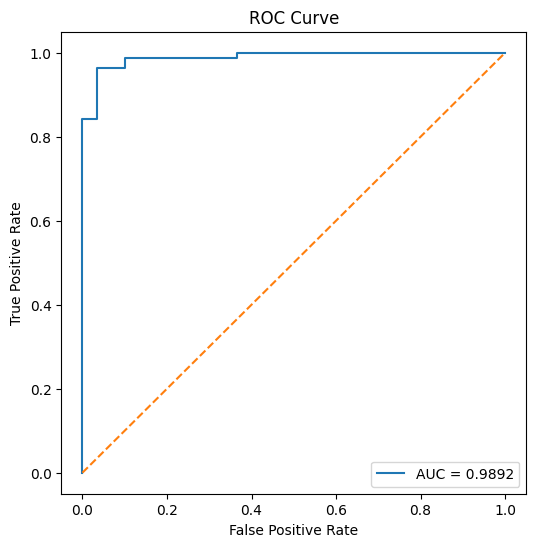

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

In [ ]:
def risk_level(prob):
    if prob < 0.30:
        return "Low Risk"
    elif prob < 0.70:
        return "Moderate Risk"
    else:
        return "High Risk"

for p in y_prob[:10]:
    print(round(p, 4), "->", risk_level(p))

1.0 -> High Risk
0.038 -> Low Risk
0.9635 -> High Risk
0.9533 -> High Risk
1.0 -> High Risk
0.0307 -> Low Risk
0.9999 -> High Risk
1.0 -> High Risk
0.0011 -> Low Risk
0.0033 -> Low Risk


In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image

In [ ]:
feature_maps = None
gradients = None

def forward_hook(module, input, output):
    global feature_maps
    feature_maps = output

def backward_hook(module, grad_input, grad_output):
    global gradients
    gradients = grad_output[0]

target_layer = model.layer4[-1]
target_layer.register_forward_hook(forward_hook)
target_layer.register_full_backward_hook(backward_hook)

In [ ]:
def generate_gradcam(model, image_tensor, class_idx=None):
    global feature_maps, gradients

    model.eval()
    output = model(image_tensor)

    if class_idx is None:
        class_idx = output.argmax(dim=1).item()

    model.zero_grad()
    score = output[:, class_idx]
    score.backward()

    pooled_gradients = torch.mean(gradients, dim=[0, 2, 3])
    fmap = feature_maps[0]

    for i in range(fmap.shape[0]):
        fmap[i, :, :] *= pooled_gradients[i]

    heatmap = torch.mean(fmap, dim=0).cpu().detach().numpy()
    heatmap = np.maximum(heatmap, 0)
    heatmap /= np.max(heatmap) + 1e-8

    return heatmap

In [ ]:
sample_img_name = test_df.iloc[0]["Image Name"]
sample_label = test_df.iloc[0]["label"]

sample_img_path = os.path.join(image_dir, sample_img_name)
sample_img = Image.open(sample_img_path).convert("RGB")

input_tensor = val_transform(sample_img).unsqueeze(0).to(device)

In [ ]:
heatmap = generate_gradcam(model, input_tensor)

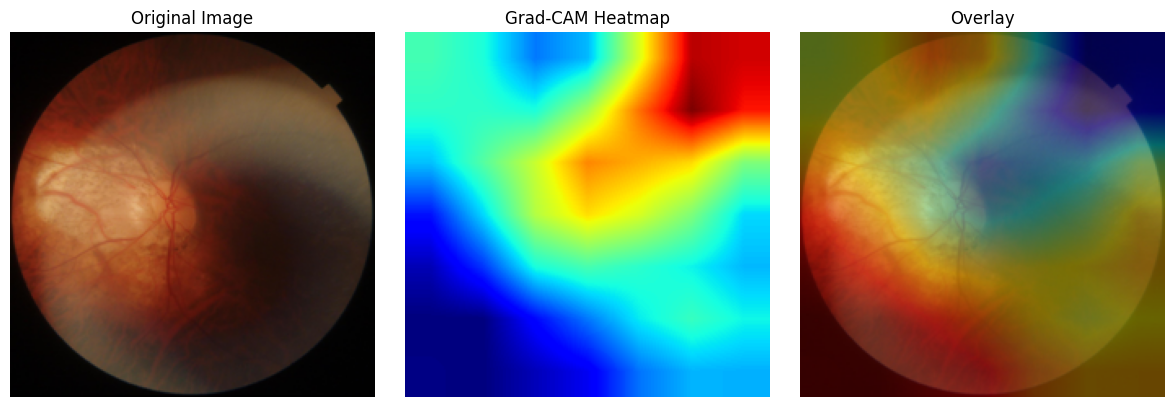

In [ ]:
img = np.array(sample_img.resize((224, 224)))
heatmap_resized = cv2.resize(heatmap, (224, 224))
heatmap_uint8 = np.uint8(255 * heatmap_resized)
heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)

overlay = cv2.addWeighted(img, 0.6, heatmap_color, 0.4, 0)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(heatmap_resized, cmap="jet")
plt.title("Grad-CAM Heatmap")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(overlay)
plt.title("Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

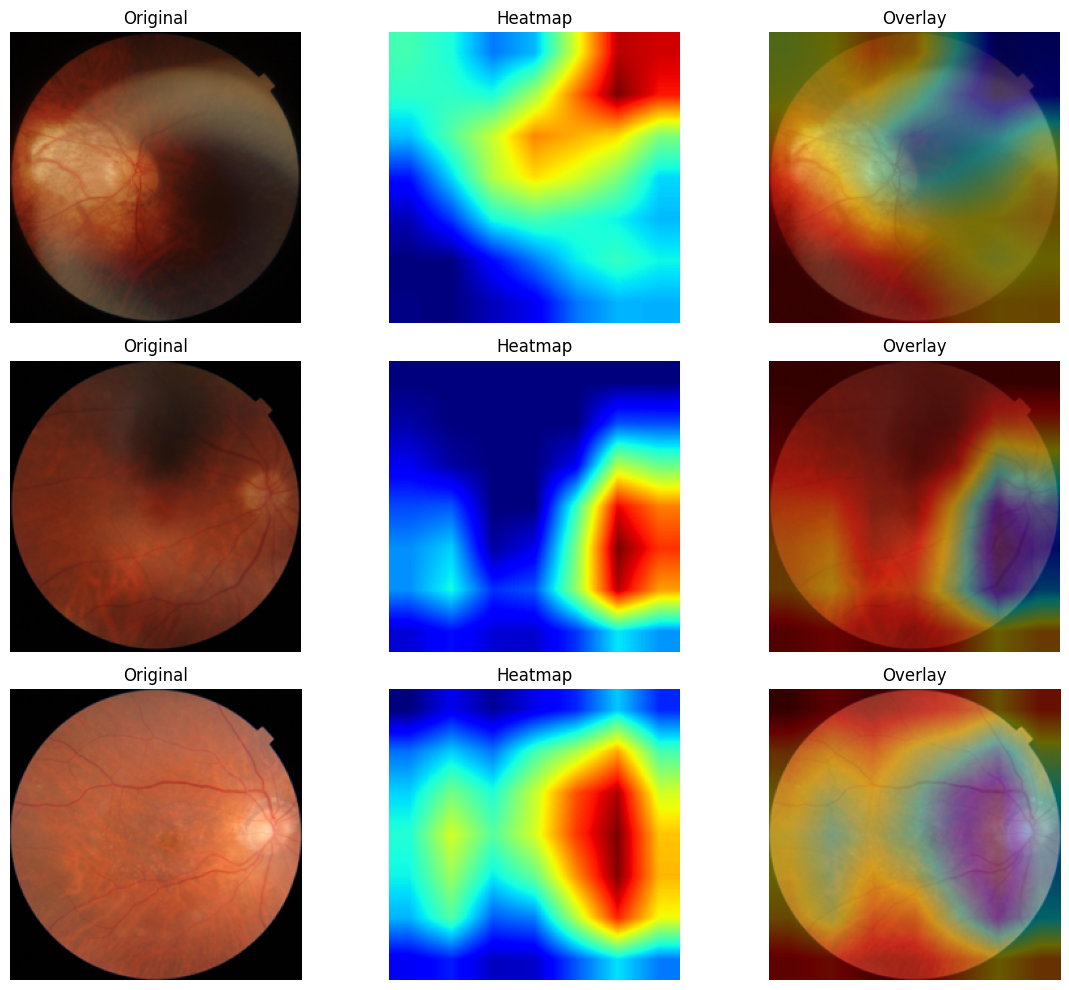

In [ ]:
indices = [0, 5, 10]

plt.figure(figsize=(12, 10))

for i, idx in enumerate(indices):
    sample_img_name = test_df.iloc[idx]["Image Name"]
    sample_img_path = os.path.join(image_dir, sample_img_name)

    sample_img = Image.open(sample_img_path).convert("RGB")
    input_tensor = val_transform(sample_img).unsqueeze(0).to(device)

    heatmap = generate_gradcam(model, input_tensor)

    img = np.array(sample_img.resize((224, 224)))
    heatmap_resized = cv2.resize(heatmap, (224, 224))
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)

    overlay = cv2.addWeighted(img, 0.6, heatmap_color, 0.4, 0)

    plt.subplot(3, 3, i*3 + 1)
    plt.imshow(img)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(3, 3, i*3 + 2)
    plt.imshow(heatmap_resized, cmap="jet")
    plt.title("Heatmap")
    plt.axis("off")

    plt.subplot(3, 3, i*3 + 3)
    plt.imshow(overlay)
    plt.title("Overlay")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
torch.save(model.state_dict(), "/content/drive/MyDrive/Colab Notebooks/HYGD/glaucoma_resnet18.pth")
print("Model saved successfully.")

Model saved successfully.
